<a href="https://colab.research.google.com/github/ananthiananthi76999-bit/Project-1/blob/main/E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving sales_data.csv to sales_data.csv
User uploaded file "sales_data.csv" with length 868 bytes


In [ ]:
import pandas as pd
df=pd.read_csv("sales_data.csv")
df

,Id,Product,Category,Quantity,Price,Date
0,101,Phone,Electronics,2,15000,2026-01-10
1,102,Shirt,Clothing,3,1000,2026-02-15
2,103,Laptop,Electronics,1,50000,2026-03-05
3,104,Rice,Grocery,5,500,2026-01-20
4,116,Saree,Clothing,2,4000,2026-08-05
5,106,TV,Electronics,1,30000,NaN
6,107,Watch,Accessories,2,3000,2026-04-05
7,108,Bag,Accessories,3,1500,2026-04-15
8,109,Milk,Grocery,4,60,2026-05-01
9,110,Bread,Grocery,5,40,2026-05-03


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Id          0
Product     0
Category    0
Quantity    0
Price       0
Date        1
dtype: int64


In [ ]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
2


In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df

,Id,Product,Category,Quantity,Price,Date
0,101,Phone,Electronics,2,15000,2026-01-10
1,102,Shirt,Clothing,3,1000,2026-02-15
2,103,Laptop,Electronics,1,50000,2026-03-05
3,104,Rice,Grocery,5,500,2026-01-20
4,116,Saree,Clothing,2,4000,2026-08-05
6,107,Watch,Accessories,2,3000,2026-04-05
7,108,Bag,Accessories,3,1500,2026-04-15
8,109,Milk,Grocery,4,60,2026-05-01
9,110,Bread,Grocery,5,40,2026-05-03
10,111,Headphones,Electronics,2,2500,2026-06-10


In [ ]:
df['total']=df['Quantity']*df['Price']
df

,Id,Product,Category,Quantity,Price,Date,total
0,101,Phone,Electronics,2,15000,2026-01-10,30000
1,102,Shirt,Clothing,3,1000,2026-02-15,3000
2,103,Laptop,Electronics,1,50000,2026-03-05,50000
3,104,Rice,Grocery,5,500,2026-01-20,2500
4,116,Saree,Clothing,2,4000,2026-08-05,8000
6,107,Watch,Accessories,2,3000,2026-04-05,6000
7,108,Bag,Accessories,3,1500,2026-04-15,4500
8,109,Milk,Grocery,4,60,2026-05-01,240
9,110,Bread,Grocery,5,40,2026-05-03,200
10,111,Headphones,Electronics,2,2500,2026-06-10,5000


In [ ]:
print(df.columns)

Index(['Id', 'Product', 'Category', 'Quantity', 'Price', 'Date', 'total'], dtype='object')


Top Selling Products:
Product
Bread           5
Rice            5
Mobile Cover    4
Saree           4
Milk            4
Name: Quantity, dtype: int64


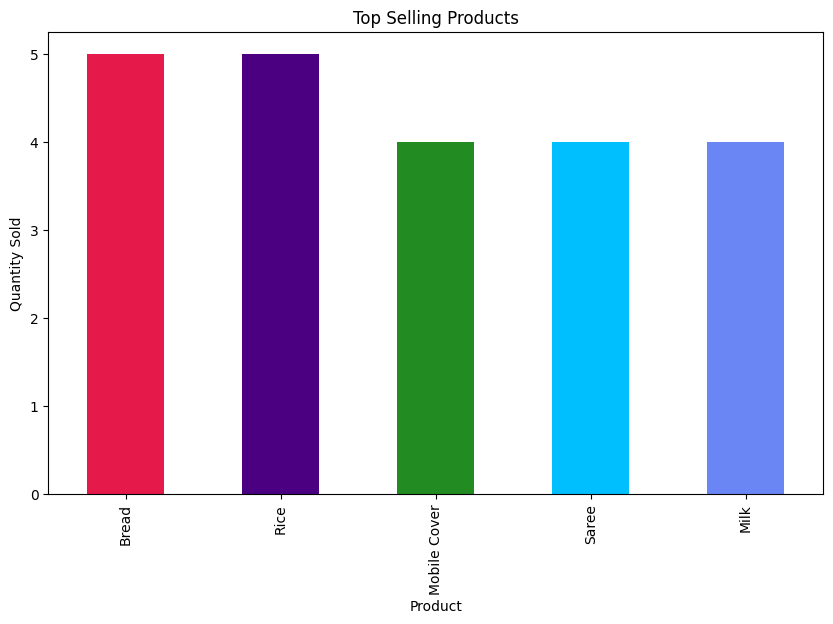

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("sales_data.csv")
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print("Top Selling Products:")
print(top_products.head())
plt.figure(figsize=(10,6))
dark_custom_colors = ['#e6194b', '#4b0082', '#228b22', '#00bfff','#6986f4']
top_products.head().plot(kind='bar', color=dark_custom_colors)
plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.show()

Monthly Sales Trend:
Month
1.0    62500
2.0     3000
3.0    50000
4.0    10500
5.0      440
6.0     8500
7.0     3600
8.0    17600
9.0     5500
Name: total, dtype: int64


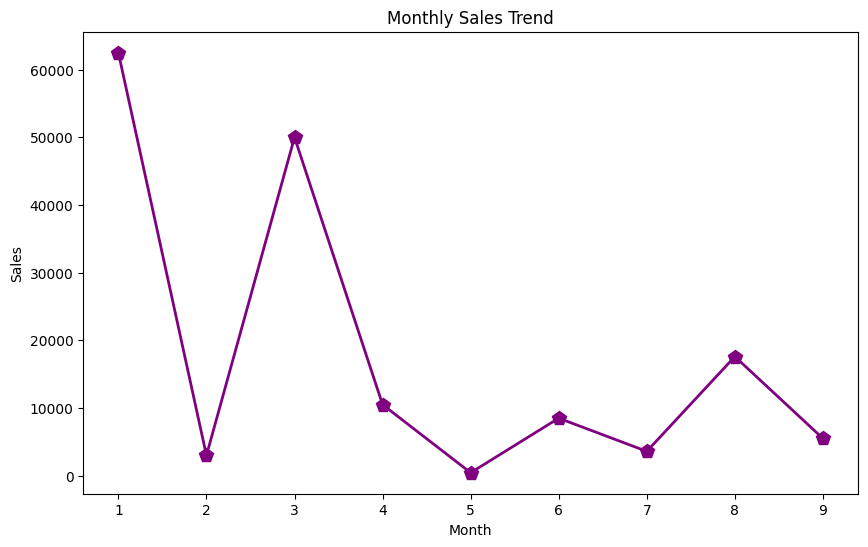

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("sales_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['total'] = df['Quantity'] * df['Price']
monthly_sales = df.groupby('Month')['total'].sum()
print("Monthly Sales Trend:")
print(monthly_sales)
plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='p', color='purple', markersize=10, linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()